In [22]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import xml.etree.ElementTree as ET
from train_test_helper import get_cell_counts, optimize_split
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import random

class BCCDDataset(Dataset):
    def __init__(self, image_dir, anno_dir, indices, transforms=None):
        """
        image_dir : folder containing the .jpg files
        anno_dir  : folder containing the .xml files
        indices   : list of integer indices for this split
                    (these are positions into the full sorted list of images)
        transforms: optional transforms
        """

    
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.indices = list(indices)          # make sure it is a list
        self.transforms = transforms
        
        # Class name → integer label
        # 0 is reserved for background by PyTorch detection models
        self.class_to_label = {
            "RBC": 1,
            "WBC": 2,
            "Platelets": 3
        }
        
        # Get a sorted list of all image file names so that
        # integer indices always point to the same image
        self.all_image_files = sorted([
            f for f in os.listdir(image_dir) if f.endswith(".jpg")
        ])
    def __len__(self):
        """
        Returns the number of images in this split.
        """
        return len(self.indices)

    def __getitem__(self, idx):
        """
        idx : position inside this split (0 to len(self)-1)
        
        Returns:
            image  : PIL Image (we will convert to tensor later)
            target : dictionary with 'boxes' and 'labels'
        """
        
        # 1. Convert the split position into the real image index
        real_idx = self.indices[idx]
        
        # 2. Get the image file name
        img_filename = self.all_image_files[real_idx]
        
        # 3. Build the full path and load the image
        img_path = os.path.join(self.image_dir, img_filename)
        image = Image.open(img_path).convert("RGB")
        
        # 4. Build the corresponding XML path
        #    "BloodImage_00000.jpg" → "BloodImage_00000.xml"
        xml_filename = img_filename.replace(".jpg", ".xml")
        xml_path = os.path.join(self.anno_dir, xml_filename)
        
        # 5. Parse the XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        boxes = []
        labels = []

        for obj in root.findall("object"):
            name = obj.find("name").text          # "RBC", "WBC", or "Platelets"
            
            # Convert class name to integer label
            label = self.class_to_label[name]
            
            bndbox = obj.find("bndbox")
            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)
            
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)
        
        # 6. Convert lists to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)    # shape [N, 4]
        labels = torch.as_tensor(labels, dtype=torch.int64)    # shape [N]
        
        # 7. Build the target dictionary
        target = {
            "boxes": boxes,
            "labels": labels
        }
        
        return image, target
    
class ToTensor:
    """
    Converts a PIL image to a PyTorch tensor.
    Does not change the target (boxes & labels).
    """
    def __call__(self, image, target):
        # F.to_tensor converts PIL → float tensor in [0, 1] with shape (C, H, W)
        image = F.to_tensor(image)
        return image, target    

class RandomHorizontalFlip:
    """
    Randomly flips the image horizontally with probability p.
    Also updates the bounding boxes so they stay correct.
    """
    def __init__(self, p=0.5):
        self.p = p          # probability of flipping

    def __call__(self, image, target):
        # Decide whether to flip
        if random.random() < self.p:
            # 1. Flip the image
            f_image = F.hflip(image)

            # 2. Flip the boxes
            # image can still be PIL or already a tensor
            if isinstance(image, torch.Tensor):
                width = image.shape[2]          # tensor is C × H × W
            else:
                width = image.width             # PIL Image
            target = target.copy()
            boxes = target["boxes"].clone()
            # boxes is a tensor of shape [N, 4] with (xmin, ymin, xmax, ymax)
            boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
            #        ^^^^               ^^^^
            #   new xmin = width - old xmax
            #   new xmax = width - old xmin

            target["boxes"] = boxes

        return f_image, target

class RandomVerticalFlip:
    """
    Randomly flips the image vertically with probability p.
        Also updates the bounding boxes so they stay correct.
    """
    def __init__(self, p=0.5):
            self.p = p          # probability of flipping
    
    def __call__(self, image, target):
        # Decide whether to flip
        if random.random() < self.p:
            # 1. Flip the image
            f_image = F.vflip(image)

            # 2. Flip the boxes
            # image can still be PIL or already a tensor
            if isinstance(image, torch.Tensor):
                height= image.shape[1]          # tensor is C × H × W
            else:
                height = image.height            # PIL Image
            target = target.copy()
            boxes = target["boxes"].clone()
            # boxes is a tensor of shape [N, 4] with (xmin, ymin, xmax, ymax)
            boxes[:, [1, 3]] = height - boxes[:, [3, 1]]
            #        ^^^^               ^^^^
            #   new ymin = height - old ymax
            #   new ymax = height - old ymin

            target["boxes"] = boxes

        return f_image, target

In [8]:
#generating train, test, val indices
jpg_dir = '../data/BCCD/JPEGImages/'
anno_dir = '../data/BCCD/Annotations/'
xml_data, rbc_counts, wbc_counts, platelet_counts = get_cell_counts(anno_dir)
train_idx, test_idx = train_test_split(np.arange(len(xml_data)), test_size=0.3, random_state=42)
train_idx, test_idx = optimize_split(rbc_counts, wbc_counts, platelet_counts, train_idx, test_idx,verbose=True, only_idx = True)
test_idx, val_idx = train_test_split(test_idx, test_size=0.5, random_state=42)
test_idx_f, val_idx = optimize_split(rbc_counts, wbc_counts, platelet_counts, test_idx, val_idx,verbose=True, only_idx = True)


Initial train loss: 0.3417
Initial test loss: 0.7890
Initial Combined Loss: 1.1307
START


100%|██████████| 9000/9000 [00:01<00:00, 6790.63it/s]



Final Train Loss: 0.0443
Final Test Loss: 0.1024
Final Combined Loss: 0.1467

Initial train loss: 0.7993
Initial test loss: 0.7908
Initial Combined Loss: 1.5901
START


100%|██████████| 9000/9000 [00:00<00:00, 9990.12it/s] 


Final Train Loss: 0.2166
Final Test Loss: 0.2146
Final Combined Loss: 0.4312


254
Image size: (640, 480)
Boxes shape: torch.Size([15, 4])
Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3])
Number of objects: 15
Boxes:  tensor([[153., 309., 243., 394.],
        [131., 401., 224., 480.],
        [377., 176., 484., 285.],
        [486., 274., 575., 362.],
        [434.,   1., 516.,  74.],
        [481.,  55., 592., 154.],
        [ 90., 118., 184., 206.],
        [274., 137., 374., 230.],
        [515.,   1., 615.,  50.],
        [561., 132., 640., 231.],
        [589., 304., 640., 388.],
        [527., 392., 638., 480.],
        [271.,  18., 398., 114.],
        [234., 332., 369., 480.],
        [282., 296., 324., 339.]])
BloodImage_00264.jpg
BloodImage_00264.xml


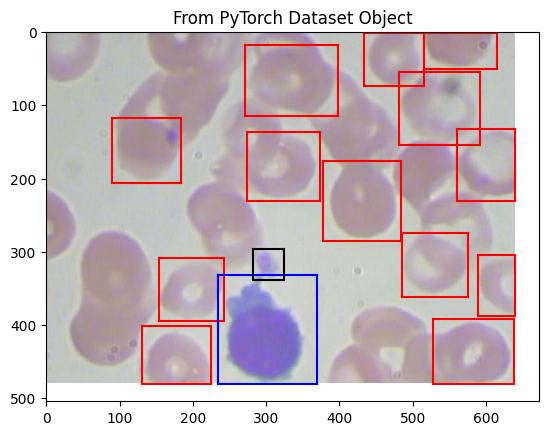

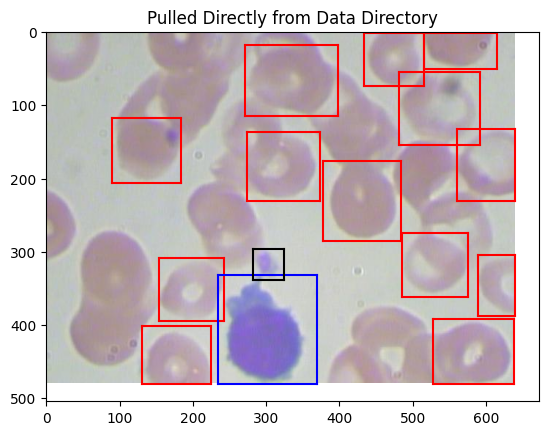

In [9]:
# cell for checking BCCDDataset class
idx= 1
bc_data = BCCDDataset(jpg_dir, anno_dir, train_idx)
print(len(bc_data.indices))
image, target = bc_data[idx]

print("Image size:", image.size)
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"])
print("Number of objects:", len(target["labels"]))
print("Boxes: ", target["boxes"])
plt.imshow(image)
plt.title("From PyTorch Dataset Object")
labels = target["labels"]
boxes = target['boxes']

for ix, item in enumerate(labels):
    cell_type = labels[ix]
    box = boxes[ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)

#sanity check
all_image_files = sorted([f for f in os.listdir(jpg_dir) if f.endswith(".jpg")])
real_idx = train_idx[idx]
pulled_img = all_image_files[real_idx]
print(pulled_img)
img_path = os.path.join(jpg_dir, pulled_img)
image = Image.open(img_path).convert("RGB")
plt.figure()
plt.imshow(image)
plt.title("Pulled Directly from Data Directory")
all_xml_files = sorted([f for f in os.listdir(anno_dir) if f.endswith(".xml")])
xml_path = os.path.join(anno_dir, all_xml_files[real_idx])
print(all_xml_files[real_idx])
tree = ET.parse(xml_path)
root = tree.getroot()

boxes = []
labels = []

for obj in root.findall("object"):
    name = obj.find("name").text          # "RBC", "WBC", or "Platelets"
    
    # Convert class name to integer label
    label = bc_data.class_to_label[name]
    bndbox = obj.find("bndbox")
    xmin = float(bndbox.find("xmin").text)
    ymin = float(bndbox.find("ymin").text)
    xmax = float(bndbox.find("xmax").text)
    ymax = float(bndbox.find("ymax").text)
    
    boxes.append([xmin, ymin, xmax, ymax])
    labels.append(label)
for ix, item in enumerate(labels):
    cell_type = labels[ix]
    box = boxes[ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)


<class 'torch.Tensor'>
torch.Size([3, 480, 640])
torch.float32
torch.Size([15, 4])
Original boxes (should be unchanged):
tensor([[153., 309., 243., 394.],
        [131., 401., 224., 480.]])

Boxes after horizontal flip:
tensor([[397., 309., 487., 394.],
        [416., 401., 509., 480.]])
Original boxes (should be unchanged):
tensor([[153., 309., 243., 394.],
        [131., 401., 224., 480.]])

After vertical flip:
tensor([[153.,  86., 243., 171.],
        [131.,   0., 224.,  79.]])


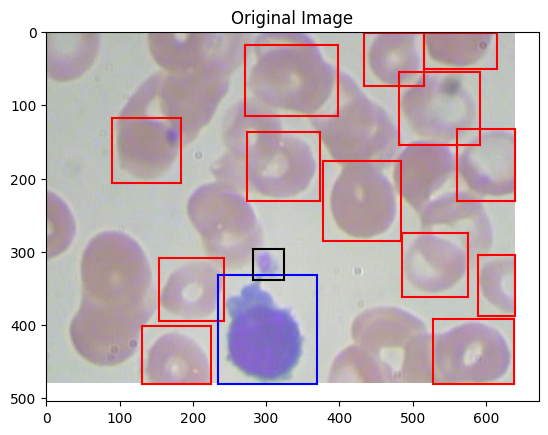

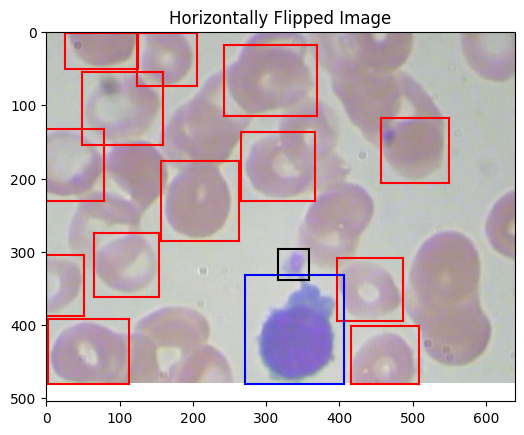

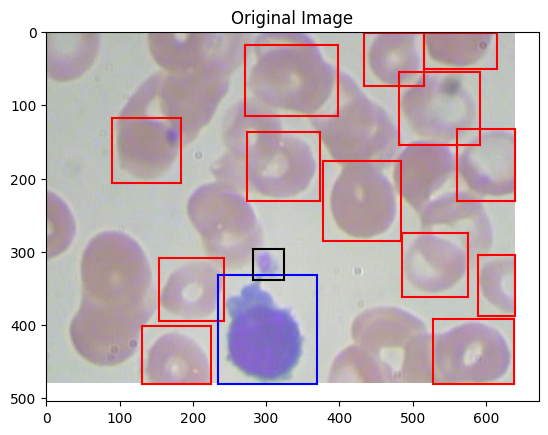

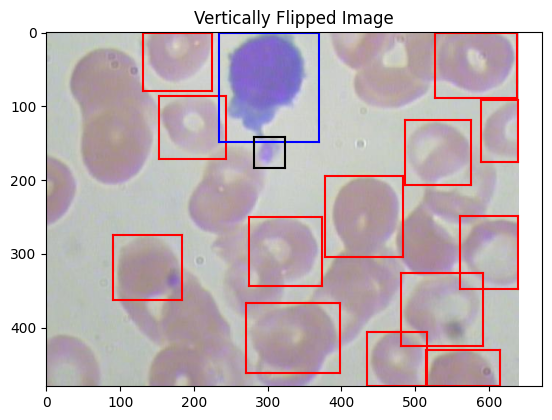

In [28]:
#cell for checking ToTensor class and RandomHorizontalFlip
# Get one sample from the dataset (still returns PIL + target)
#ToTensor check
image, target = bc_data[idx]
# Apply the transform
transform = ToTensor()
image_t, target_t = transform(image, target)
print(type(image_t))
print(image_t.shape)          # should be [3, H, W]
print(image_t.dtype)
print(target_t["boxes"].shape)
#---------------------------------------------------

#RandomHorizontalFlip check
image, target = bc_data[idx]
plt.imshow(image)
for ix, item in enumerate(target['boxes']):
    cell_type = target['labels'][ix]
    box = target['boxes'][ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)
plt.title('Original Image')
# Keep a copy of the original boxes for comparison
original_boxes = target["boxes"].clone()

transform = RandomHorizontalFlip(p=1.0)
image_f, target_f = transform(image, target)
plt.figure()
plt.imshow(image_f)
for ix, item in enumerate(target_f['boxes']):
    cell_type = target_f['labels'][ix]
    box = target_f['boxes'][ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)
plt.title("Horizontally Flipped Image")
print("Original boxes (should be unchanged):")
print(original_boxes[:2])
print("\nBoxes after horizontal flip:")
print(target_f["boxes"][:2])

#-----------------------------
#Random Vertical Flip Check
image, target = bc_data[idx]

original_boxes = target["boxes"].clone()

transform = RandomVerticalFlip(p=1.0)      # always flip for testing
image_v, target_v = transform(image, target)

print("Original boxes (should be unchanged):")
print(original_boxes[:2])
print("\nAfter vertical flip:")
print(target_v["boxes"][:2])

plt.figure()
plt.imshow(image)
for ix, item in enumerate(target['boxes']):
    cell_type = target['labels'][ix]
    box = target['boxes'][ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)
plt.title('Original Image')

plt.figure()
plt.imshow(image_v)
plt.title('Vertically Flipped Image')
for ix, item in enumerate(target_v['boxes']):
    cell_type = target_v['labels'][ix]
    box = target_v['boxes'][ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)
